In [1]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# PASO 1: Cargar los datos             
# Cargar el conjunto de datos (Descargado de Kaggle)
file = "2. Datos/IPM - 2021.xlsx"
df = pd.read_excel(file,sheet_name="Datos")
# Mostrar las primeras filas del conjunto de datos
df = df.set_index('Dpto')
print(df.head())

       Año            Región  Analfab  B_Ledu  B_Servcpi  B_Accss  Ds_Ld  \
Dpto                                                                       
Amaz  2021   Región Amazonía      6.9    51.5       10.0      0.9   12.3   
Anti  2021     Región Andina      8.3    39.2        7.9      2.0   15.2   
Arau  2021  Región Orinoquía      6.9    54.9       11.6      0.7   11.9   
Atla  2021     Región Caribe      7.4    30.0       12.4      1.2    8.2   
Bog   2021  Distrito Capital      1.8    20.6        6.6      3.4   16.2   

        Hc  Inad_Ee  Ina_Esc  Mt_Pext  Mt_Pisos  Rez_Esc  Sin_Fagua  \
Dpto                                                                  
Amaz  17.4     36.6      5.0     22.2       2.1     44.1       44.8   
Anti   6.4      8.9      3.4      1.2       2.0     22.8        8.4   
Arau   8.9     12.5      9.3     13.3      18.8     26.8        5.8   
Atla  10.4      7.1     11.0      1.3       2.1     30.5        2.2   
Bog    6.4      1.0      2.9      0.9    

In [3]:
# 2. Preprocesamiento: Estandarizar los datos (Crucial para PCA)
# Manejo de valores faltantes en columnas numéricas
numeric_columns = df.select_dtypes(include=['number']).columns.difference(["Año"])
# Normalización de los datos (solo columnas numéricas)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric_columns])
# Convertir el resultado en un DataFrame usando las columnas numéricas
df_scaled = pd.DataFrame(df_scaled, columns=numeric_columns)
n = df_scaled.shape[0]  # número de individuos
df_scaled

,Analfab,B_Accss,B_Ledu,B_Servcpi,Ds_Ld,Hc,Ina_Esc,Inad_Ee,Mt_Pext,Mt_Pisos,Rez_Esc,Sin_Asalud,Sin_Fagua,Trab_Infan,Trab_Infor
0,-0.648713,-0.723085,0.161464,0.400317,-0.382149,1.227046,-0.526620,0.632104,1.739212,-0.628704,2.530660,-1.060430,0.848916,0.422507,0.154311
1,-0.423371,0.016295,-0.904198,-0.383354,0.127205,-0.639751,-1.053241,-0.577708,-0.686374,-0.635180,-0.797934,-0.058210,-0.706718,-0.397653,-1.285436
2,-0.648713,-0.857517,0.456037,0.997399,-0.452404,-0.215479,0.888672,-0.420476,0.711225,0.452691,-0.172846,3.031969,-0.817835,-0.397653,1.323501
3,-0.568234,-0.521436,-1.701279,1.295941,-1.102270,0.039084,1.448206,-0.656324,-0.674824,-0.628704,0.405360,0.275864,-0.971689,-1.100648,-0.599382
4,-1.469603,0.957323,-2.515688,-0.868484,0.302845,-0.639751,-1.217810,-0.922744,-0.721026,-0.732311,-1.094851,0.380262,-1.027247,-1.334979,-2.435300
5,0.429711,-0.857517,-0.453674,0.437634,-0.505096,0.751862,0.592448,0.627736,-0.259009,0.310231,0.389733,-0.287885,-0.279346,-0.163322,0.163974
6,-0.616521,-0.118138,-0.011814,-1.241660,0.390664,-0.826431,-1.086155,-0.638853,-0.744126,-0.479770,-0.907325,-0.768116,-0.591327,-0.397653,-0.502755
7,-0.568234,0.688458,-0.297724,-1.428249,0.337973,-1.233732,-1.184896,-0.831026,-0.709475,-0.738786,-0.876071,-0.371404,-0.655433,-0.631985,-1.469027
8,-0.230220,0.957323,0.958545,0.288364,-0.276765,-0.385188,0.329138,-0.376800,-0.074203,-0.369687,0.686650,-0.580199,-0.155408,2.414325,0.724412
9,-0.680905,-0.454219,-0.167765,-0.122131,-0.505096,0.056055,0.658276,-0.634486,-0.201257,-0.350261,-0.204101,0.150586,-0.702444,0.071010,-0.106583


In [4]:
# Aplicar PCA
pca = PCA(n_components=2)  # Intentemos reducir a 2 componentes principales
df_pca = pca.fit_transform(df_scaled)

In [5]:
df_pca

array([[ 1.80794228, -1.23573659],
       [-2.3262692 , -0.7596598 ],
       [ 0.77513859,  1.89488784],
       [-1.03839718,  0.54269912],
       [-4.06271959, -1.4611474 ],
       [ 0.78722283, -0.05827965],
       [-2.1652799 , -0.92655559],
       [-2.96228937, -0.95045941],
       [ 0.25927535,  1.91623886],
       [-0.8344259 ,  0.5896069 ],
       [-0.77846153,  0.69223222],
       [ 0.78934399,  1.19810685],
       [ 3.04309718, -1.59638062],
       [ 0.65859612, -0.15191723],
       [-2.41402056, -0.62304432],
       [ 4.97462639, -1.36953216],
       [ 0.66958382,  2.02870334],
       [-0.53280457,  1.30147402],
       [ 4.98490285,  1.89661776],
       [ 1.65995078,  1.52056327],
       [-1.67328233, -0.1328245 ],
       [-0.61292132,  1.17208423],
       [-0.46847344,  3.97027342],
       [-0.40822011,  0.45485592],
       [-2.82157632, -0.60139759],
       [-2.78066993, -1.14899648],
       [-1.73723884, -3.89222435],
       [-1.98554969,  0.26377659],
       [ 1.63801634,

In [6]:
# Convertir el resultado en un DataFrame para mejor interpretación
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

In [7]:
# Varianza explicada por cada componente (en %)
var_exp_PC1 = pca.explained_variance_ratio_[0] * 100
var_exp_PC2 = pca.explained_variance_ratio_[1] * 100

In [8]:
var_exp_PC2

np.float64(15.921219974990395)

In [9]:
# Ver la cantidad de variabilidad capturada por cada componente
print('proporción de varianza explicada:', pca.explained_variance_ratio_)
print('Suma de la varianza explicada:', sum(pca.explained_variance_ratio_))

proporción de varianza explicada: [0.44778174 0.1592122 ]
Suma de la varianza explicada: 0.606993940506076


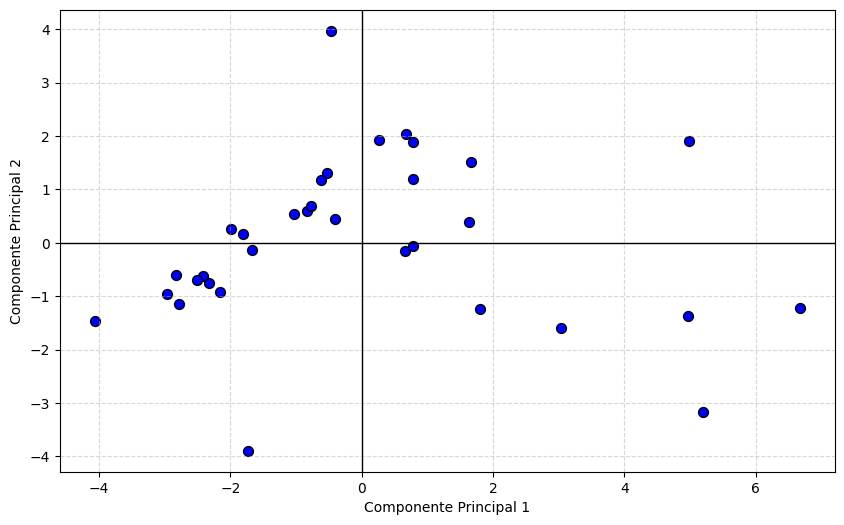

In [10]:
# Graficar los dos primeros componentes principales con líneas en el origen
plt.figure(figsize=(10, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c='blue', edgecolor='k', s=50)

# Añadir líneas del origen
plt.axhline(0, color='black', linewidth=1)  # línea horizontal en y=0
plt.axvline(0, color='black', linewidth=1)  # línea vertical en x=0

# Configuración del gráfico
plt.title('')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [11]:
def generar_circulo_correlaciones(pca_modelo, variables):
    """
    Genera y muestra el Círculo de Correlaciones para un modelo PCA,
    con los ejes centrados en el origen (0,0).
    """
    # 1. Calcular las coordenadas (loadings)
    loadings = pca_modelo.components_.T * np.sqrt(pca_modelo.explained_variance_)
    
    # 2. Crear DataFrame para facilidad
    loadings_df = pd.DataFrame(loadings, columns=['CP1', 'CP2'], index=variables)

    # 3. Crear figura
    fig, ax = plt.subplots(figsize=(8, 8))

    # 4. Dibujar círculo de radio 1
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
    ax.add_artist(circle)

    # 5. Dibujar ejes en el origen
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)

    # 6. Dibujar las flechas (vectores) desde el origen
    for i in range(loadings_df.shape[0]):
        ax.arrow(0, 0,
                 loadings_df['CP1'][i],
                 loadings_df['CP2'][i],
                 head_width=0.04, head_length=0.04,
                 fc='blue', ec='blue', alpha=0.8)
        ax.text(loadings_df['CP1'][i] * 1.1,
                loadings_df['CP2'][i] * 1.1,
                loadings_df.index[i],
                color='darkred', ha='center', va='center', fontsize=9)

    # 7. Configurar los límites centrados en 0
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal', adjustable='box')

    # 8. Etiquetas y título
    ax.set_xlabel("Componente Principal 1", fontsize=12)
    ax.set_ylabel("Componente Principal 2", fontsize=12)
    ax.set_title("Círculo de Correlaciones (centrado en el origen)", fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.show()
 

In [12]:
df = df
variables = list(set(df.columns) - set(["Año", "Región"]))
variables

['Ds_Ld',
 'B_Ledu',
 'Trab_Infan',
 'Ina_Esc',
 'Rez_Esc',
 'Inad_Ee',
 'B_Servcpi',
 'Sin_Asalud',
 'Mt_Pext',
 'Hc',
 'B_Accss',
 'Trab_Infor',
 'Sin_Fagua',
 'Mt_Pisos',
 'Analfab']

In [13]:
# Observar 
pca.fit(df_scaled)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


C:\Users\Claudia Montes\AppData\Local\Temp\ipykernel_12864\4619354.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  loadings_df['CP1'][i],
C:\Users\Claudia Montes\AppData\Local\Temp\ipykernel_12864\4619354.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  loadings_df['CP2'][i],
C:\Users\Claudia Montes\AppData\Local\Temp\ipykernel_12864\4619354.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(loadings_df['CP1'][i] 

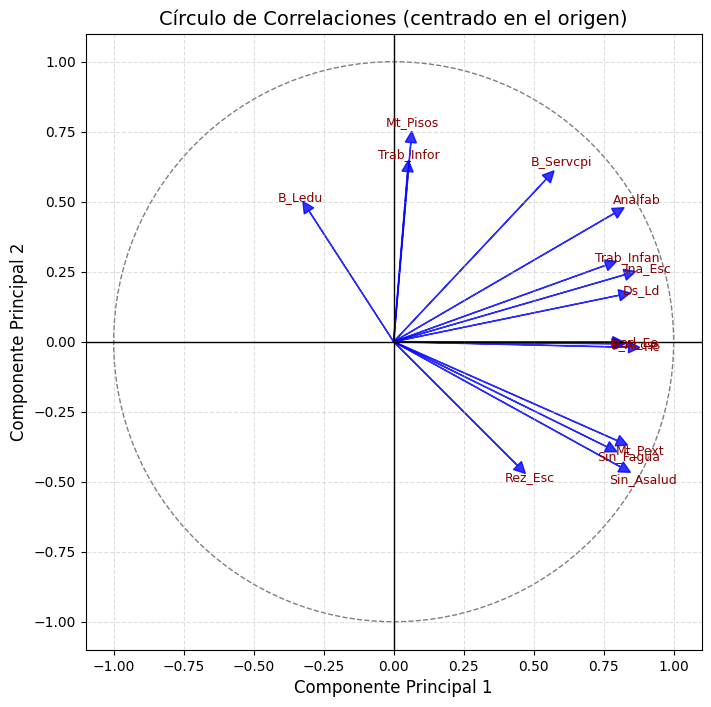

In [14]:
# 4. Generar el Círculo de Correlaciones
generar_circulo_correlaciones(pca, variables)